# Laboratorul 2 - Inteligență Artificială Generativă
# Autoencoder clasic (AE) și autoencoder variațional (VAE) pe MNIST

## Scopul laboratorului

În acest notebook învățăm, pas cu pas, cum funcționează două modele generative:

1. **Autoencoderul clasic (AE)** învață să comprime o imagine și apoi să o reconstruiască.
2. **Autoencoderul variațional (VAE)** face același lucru, dar organizează și spațiul latent astfel încât să poată genera imagini noi mai ușor.

Vom lucra cu imagini MNIST, adică imagini alb-negru cu cifre scrise de mână. La final vom compara:

- cât de bine reconstruiește fiecare model imaginile;
- cum arată reprezentările interne, numite **spațiu latent**;
- ce fel de imagini noi poate genera fiecare model.

    ## Ideea principală

Un autoencoder are două părți:

- **Encoderul** primește imaginea și o transformă într-un vector scurt `z`.
- **Decoderul** primește vectorul `z` și încearcă să refacă imaginea inițială.

Imaginea trece printr-un „gât de sticlă” (bottleneck). Deoarece vectorul `z` este mai mic decât imaginea, modelul trebuie să păstreze în el doar informațiile importante.

În acest laborator vom considera că modelul a învățat bine dacă imaginea reconstruită seamănă cu imaginea originală, iar eroarea de reconstrucție este mică.

## 1. Pregătirea experimentului și încărcarea datelor

Înainte să construim modelele, avem nevoie de trei lucruri:

1. bibliotecile Python pentru rețele neuronale și grafice;
2. setul de date MNIST;
3. un mod de a trimite imaginile către model în loturi (batch-uri).

### Ce este MNIST?

MNIST conține imagini de dimensiune `28 x 28` cu cifre de la `0` la `9`. Fiecare imagine are o etichetă, dar autoencoderul nu folosește eticheta pentru reconstrucție. El vede doar imaginea și învață să o copieze.

### Ce înseamnă `ToTensor()`?

Pixelii unei imagini sunt transformați în numere între `0` și `1`. Astfel, `0` înseamnă negru, iar `1` înseamnă alb. Această scalare ajută rețeaua să învețe mai stabil.

### Parametrii experimentului

- `BATCH`: câte imagini procesăm simultan;
- `LATENT`: numărul de valori din reprezentarea comprimată;
- `EPOCHS`: de câte ori vede modelul întregul set de antrenare;
- `LR`: rata de învățare, adică mărimea pașilor făcuți de optimizer.

Rulăm următoarea celulă și verificăm dacă datele au forma așteptată.

In [1]:
# Import bibliotecile folosite în experiment.
import random
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Fixăm semințele ca să putem reproduce rezultatele experimentului.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispozitiv folosit:', device)

BATCH = 128
LATENT = 16
EPOCHS = 10
LR = 1e-3

# MNIST este deja în intervalul [0, 1] după ToTensor(), potrivit pentru Sigmoid.
tf = transforms.Compose([transforms.ToTensor()])
train_ds = datasets.MNIST('./data', train=True, download=True, transform=tf)
test_ds = datasets.MNIST('./data', train=False, download=True, transform=tf)

# num_workers=0 evită problemele de multiprocessing întâlnite frecvent pe Windows.
train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=0)
test_dl = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=0)

x0, y0 = train_ds[0]
print(f'Datele de antrenare: {len(train_ds)} imagini, forma unei imagini: {tuple(x0.shape)}')
print(f'Datele de test: {len(test_ds)} imagini, valori în [{x0.min().item():.1f}, {x0.max().item():.1f}]')

Dispozitiv folosit: cpu


100%|██████████| 9.91M/9.91M [00:03<00:00, 2.69MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 213kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 1.90MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 1.84MB/s]


Datele de antrenare: 60000 imagini, forma unei imagini: (1, 28, 28)
Datele de test: 10000 imagini, valori în [0.0, 1.0]


## 2. Autoencoderul clasic (AE)

### Intuiție

Un autoencoder clasic încearcă să copieze o imagine. Totuși, nu îi permitem să copieze direct toți cei `784` pixeli. Imaginea este mai întâi comprimată într-un vector mai mic, de dimensiune `LATENT = 16`.

Fluxul este:

`imagine 28 x 28 -> 784 valori -> encoder -> vector z cu 16 valori -> decoder -> imagine reconstruită 28 x 28`

- **Encoderul** învață să păstreze informația importantă.
- **Vectorul latent `z`** este rezumatul numeric al imaginii.
- **Decoderul** învață să transforme rezumatul înapoi într-o imagine.

AE este determinist: aceeași imagine produce, în mod normal, exact același vector `z`.

### Cum învață AE?

Comparăm imaginea originală `x` cu reconstrucția `x_hat`. Folosim MSE (mean squared error):

$$
MSE = \frac{1}{N}\sum_{i=1}^{N}(x_i - \hat{x}_i)^2
$$

Dacă MSE este mic, pixelii reconstruiți sunt apropiați de pixelii originali. În această secțiune definim arhitectura AE; antrenarea se face mai jos, după ce definim funcțiile comune.

In [2]:
class AE(nn.Module):
    """Autoencoder determinist: encoderul produce direct vectorul z."""
    def __init__(self, latent=16):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
            nn.Linear(128, latent)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid()
        )

    def encode(self, x):
        return self.encoder(x.view(-1, 784))

    def decode(self, z):
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x):
        return self.decode(self.encode(x))

## 3. Autoencoderul variațional (VAE)

### De ce avem nevoie de VAE?

AE este bun la reconstrucție, dar vectorii lui latenți pot fi împrăștiați într-un mod neregulat. Dacă alegem la întâmplare un vector `z`, nu știm dacă decoderul va produce o imagine utilă.

VAE rezolvă această problemă printr-o idee importantă: encoderul nu produce un singur punct latent, ci parametrii unei distribuții normale:

- `mu` = centrul distribuției;
- `logvar` = logaritmul varianței, folosit pentru stabilitate numerică;
- `sigma = exp(0.5 * logvar)` = abaterea standard.

Apoi alegem un punct aleator:

$$
z = \mu + \sigma \cdot \epsilon, \quad \epsilon \sim N(0, I)
$$

Acest pas se numește **reparametrizare**. El introduce aleatorietate, dar păstrează posibilitatea de a calcula gradientul și de a antrena rețeaua.

### Pierderea VAE

VAE are două obiective:

1. **Pierderea de reconstrucție:** imaginea generată trebuie să semene cu imaginea originală.
2. **Pierderea KL:** distribuția latentă trebuie să fie apropiată de distribuția normală standard `N(0, I)`.

Formula folosită este:

$$
L_{VAE} = L_{reconstrucție} + L_{KL}
$$

Termenul KL face spațiul latent mai ordonat și permite eșantionarea unor vectori noi din `N(0, I)`. Prețul este că reconstrucțiile pot fi mai puțin exacte decât la AE.

In [3]:
class VAE(nn.Module):
    """VAE cu distribuție latentă aproximată prin N(mu, sigma^2)."""
    def __init__(self, latent=16):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        self.mu = nn.Linear(128, latent)
        self.logvar = nn.Linear(128, latent)
        self.dec = nn.Sequential(
            nn.Linear(latent, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 784), nn.Sigmoid()
        )
        self.latent = latent

    def encode(self, x):
        h = self.enc(x.view(-1, 784))
        return self.mu(h), self.logvar(h)

    def reparameterize(self, mu, logvar):
        # Trucul de reparametrizare păstrează gradientul prin mu și logvar.
        std = torch.exp(0.5 * logvar)
        return mu + torch.randn_like(std) * std

    def decode(self, z):
        return self.dec(z).view(-1, 1, 28, 28)

    def forward(self, x):
        mu, logvar = self.encode(x)
        return self.decode(self.reparameterize(mu, logvar)), mu, logvar


def vae_loss(x, x_hat, mu, logvar, beta=1.0):
    # Toate componentele sunt mediate pe imagini pentru comparații corecte.
    recon = F.mse_loss(x_hat, x, reduction='sum') / x.size(0)
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp()) / x.size(0)
    return recon + beta * kl, recon, kl

## 4. Funcțiile de antrenare și evaluare

În această secțiune scriem codul care poate fi folosit pentru ambele modele.

### Ce se întâmplă într-un pas de antrenare?

Pentru fiecare batch de imagini:

1. modelul produce o reconstrucție;
2. calculăm cât de mare este eroarea;
3. `backward()` calculează gradientul pentru fiecare parametru;
4. optimizerul `Adam` actualizează parametrii;
5. repetăm procesul pentru toate batch-urile.

O **epocă** înseamnă că modelul a văzut toate cele 60.000 de imagini de antrenare o dată.

### De ce folosim două moduri de evaluare?

Pentru AE, reconstrucția este direct `model(x)`. Pentru VAE, la evaluare folosim `mu`, nu un eșantion aleatoriu. Astfel, MSE-ul măsurat este stabil și comparația dintre modele este mai corectă.

Vom salva separat:

- pierderea totală;
- eroarea de reconstrucție;
- termenul KL pentru VAE;
- MSE-ul calculat pe setul de test.

In [4]:
def evaluate(model, vae=False):
    """Calculează MSE-ul pe test; pentru VAE folosim mu pentru reconstrucție stabilă."""
    model.eval()
    total_mse = 0.0
    total_items = 0
    with torch.no_grad():
        for x, _ in test_dl:
            x = x.to(device)
            if vae:
                mu, _ = model.encode(x)
                x_hat = model.decode(mu)
            else:
                x_hat = model(x)
            total_mse += F.mse_loss(x_hat, x, reduction='sum').item()
            total_items += x.numel()
    return total_mse / total_items


def train_model(model, epochs=EPOCHS, vae=False):
    optimizer = optim.Adam(model.parameters(), lr=LR)
    history = {'total': [], 'reconstruction': [], 'kl': [], 'test_mse': []}

    for epoch in range(epochs):
        model.train()
        sums = {'total': 0.0, 'reconstruction': 0.0, 'kl': 0.0}
        for x, _ in train_dl:
            x = x.to(device)
            optimizer.zero_grad()
            if vae:
                x_hat, mu, logvar = model(x)
                loss, recon, kl = vae_loss(x, x_hat, mu, logvar)
            else:
                x_hat = model(x)
                recon = F.mse_loss(x_hat, x, reduction='sum') / x.size(0)
                kl = torch.tensor(0.0, device=device)
                loss = recon
            loss.backward()
            optimizer.step()
            batch_size = x.size(0)
            sums['total'] += loss.item() * batch_size
            sums['reconstruction'] += recon.item() * batch_size
            sums['kl'] += kl.item() * batch_size

        for key in sums:
            history[key].append(sums[key] / len(train_ds))
        history['test_mse'].append(evaluate(model, vae=vae))
        print(
            f"Epoca {epoch + 1:02d}/{epochs} | "
            f"loss={history['total'][-1]:.4f} | "
            f"recon={history['reconstruction'][-1]:.4f} | "
            f"KL={history['kl'][-1]:.4f} | "
            f"MSE test={history['test_mse'][-1]:.5f}"
        )
    return history

## 5. Antrenarea celor două modele

Antrenăm AE și VAE cu același set de date, același batch size și aceeași dimensiune latentă. În acest fel, comparația este mai echitabilă.

Folosim aceeași valoare `SEED` pentru a obține rezultate reproductibile. Rezultatele exacte pot varia puțin între calculatoare, mai ales dacă se folosește GPU, dar tendința ar trebui să fie asemănătoare.

În timpul rulării, pentru fiecare epocă afișăm:

- `loss`: pierderea optimizată de model;
- `recon`: eroarea de reconstrucție;
- `KL`: regularizarea VAE; la AE este zero;
- `MSE test`: eroarea pe imagini pe care modelul nu le-a folosit la antrenare.

Un MSE de test mai mic înseamnă reconstrucții mai apropiate de imaginile originale. Pentru VAE, nu trebuie să ne uităm doar la MSE: și organizarea spațiului latent și generarea de imagini sunt obiective importante.

In [5]:
# Antrenăm cele două modele în condiții cât mai apropiate.
torch.manual_seed(SEED)
ae = AE(LATENT).to(device)
hist_ae = train_model(ae, vae=False)

# Resetăm sămânța doar pentru o inițializare reproductibilă a VAE-ului.
torch.manual_seed(SEED)
vae_m = VAE(LATENT).to(device)
hist_vae = train_model(vae_m, vae=True)

Epoca 01/10 | loss=39.1942 | recon=39.1942 | KL=0.0000 | MSE test=0.02904
Epoca 02/10 | loss=19.6339 | recon=19.6339 | KL=0.0000 | MSE test=0.02125
Epoca 03/10 | loss=15.4901 | recon=15.4901 | KL=0.0000 | MSE test=0.01793
Epoca 04/10 | loss=13.4466 | recon=13.4466 | KL=0.0000 | MSE test=0.01576
Epoca 05/10 | loss=11.9780 | recon=11.9780 | KL=0.0000 | MSE test=0.01431
Epoca 06/10 | loss=10.9652 | recon=10.9652 | KL=0.0000 | MSE test=0.01321
Epoca 07/10 | loss=10.2663 | recon=10.2663 | KL=0.0000 | MSE test=0.01252
Epoca 08/10 | loss=9.7795 | recon=9.7795 | KL=0.0000 | MSE test=0.01206
Epoca 09/10 | loss=9.4066 | recon=9.4066 | KL=0.0000 | MSE test=0.01170
Epoca 10/10 | loss=9.0942 | recon=9.0942 | KL=0.0000 | MSE test=0.01136
Epoca 01/10 | loss=51.2979 | recon=49.0292 | KL=2.2688 | MSE test=0.04415
Epoca 02/10 | loss=38.3594 | recon=31.9168 | KL=6.4426 | MSE test=0.03218
Epoca 03/10 | loss=34.5609 | recon=26.9379 | KL=7.6230 | MSE test=0.02808
Epoca 04/10 | loss=33.0537 | recon=24.8413 |

## 6. Compararea reconstrucțiilor

Acum verificăm dacă modelele au învățat să refacă imaginile.

### Cum citim rezultatul numeric?

MSE-ul este o medie a erorilor de pe toți pixelii. De exemplu, `0.01` înseamnă că eroarea pătratică medie pe pixel este mică. Nu este un procent și nu trebuie interpretat ca „modelul este corect în 99% din cazuri”.

Ne așteptăm ca AE să aibă MSE mai mic, deoarece își concentrează toată capacitatea pe reconstrucție. VAE are și o a doua sarcină: să țină distribuția latentă aproape de `N(0, I)`.

### Cum citim imaginile?

- primul rând: imaginile originale;
- al doilea rând: reconstrucțiile AE;
- al treilea rând: reconstrucțiile VAE.

Contururile ușor neclare la VAE sunt normale. VAE introduce aleatorietate și preferă un spațiu latent continuu, ceea ce este util pentru generare, chiar dacă uneori pierde detalii fine.

Graficul din stânga arată MSE-ul pe test de la o epocă la alta. Graficul din dreapta separă cele două componente importante ale pierderii VAE.

MSE test AE :  0.011364
MSE test VAE:  0.021706
Raport MSE VAE/AE: 1.91


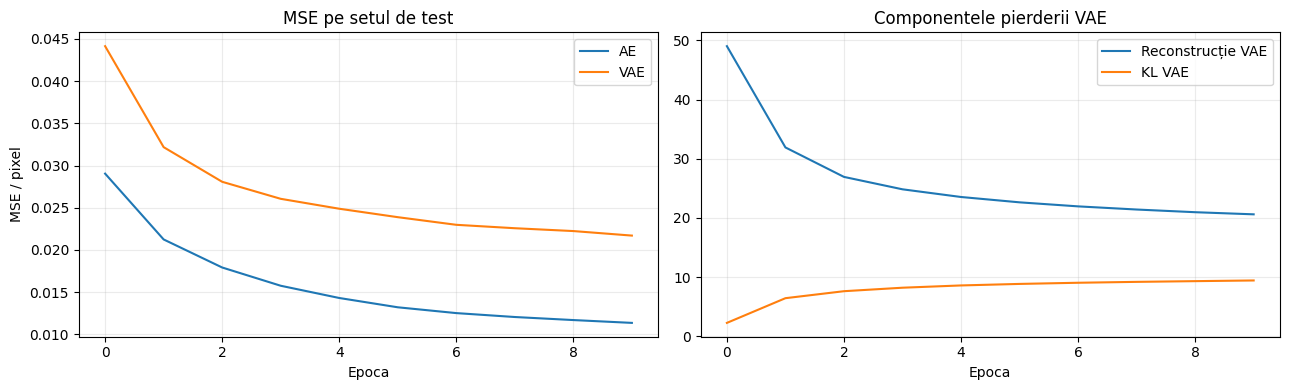

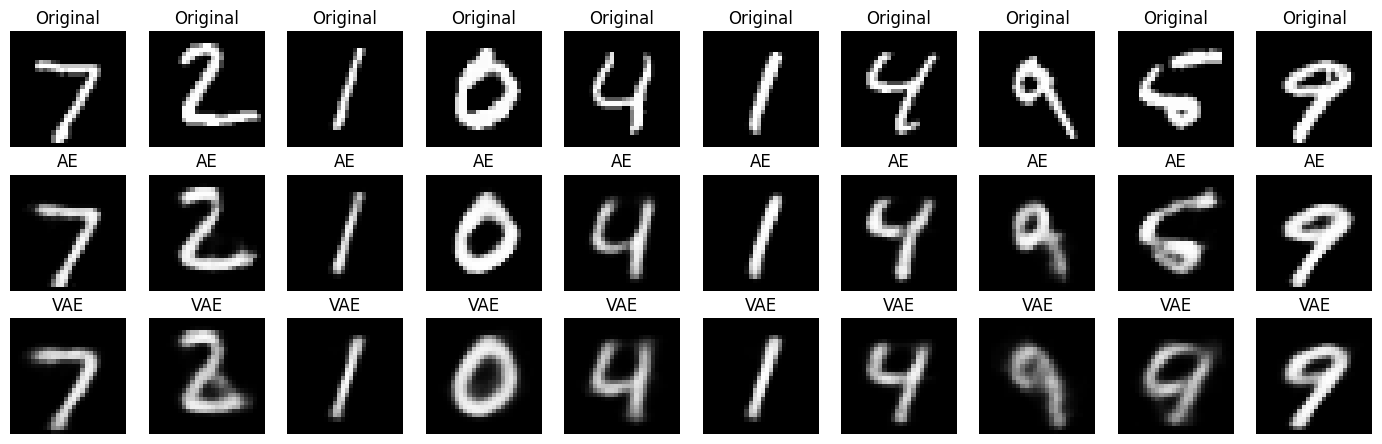

In [6]:
# Comparăm aceeași metrică: MSE mediu pe pixel și pe imaginea de test.
mse_ae = evaluate(ae, vae=False)
mse_vae = evaluate(vae_m, vae=True)
print(f'MSE test AE :  {mse_ae:.6f}')
print(f'MSE test VAE:  {mse_vae:.6f}')
print(f'Raport MSE VAE/AE: {mse_vae / mse_ae:.2f}')

# Graficul pierderilor arată compromisul dintre fidelitatea reconstrucției și regularizarea KL.
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(hist_ae['test_mse'], label='AE')
axes[0].plot(hist_vae['test_mse'], label='VAE')
axes[0].set_title('MSE pe setul de test')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('MSE / pixel')
axes[0].legend()
axes[0].grid(alpha=0.25)
axes[1].plot(hist_vae['reconstruction'], label='Reconstrucție VAE')
axes[1].plot(hist_vae['kl'], label='KL VAE')
axes[1].set_title('Componentele pierderii VAE')
axes[1].set_xlabel('Epoca')
axes[1].legend()
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.savefig('loss_comparison.png', dpi=140)
plt.show()

# Pentru VAE folosim media mu, ca imaginile să nu varieze între rulări.
x, labels = next(iter(test_dl))
x = x.to(device)
with torch.no_grad():
    rec_ae = ae(x)
    mu, _ = vae_m.encode(x)
    rec_vae = vae_m.decode(mu)

fig, axes = plt.subplots(3, 10, figsize=(14, 4.5))
for i in range(10):
    images = (x[i], rec_ae[i], rec_vae[i])
    titles = ('Original', 'AE', 'VAE')
    for row, (image, title) in enumerate(zip(images, titles)):
        axes[row, i].imshow(image[0].cpu(), cmap='gray', vmin=0, vmax=1)
        axes[row, i].set_title(title)
        axes[row, i].axis('off')
plt.tight_layout()
plt.savefig('reconstructions.png', dpi=140)
plt.show()

## 7. Generarea unor imagini noi

Până acum am reconstruit imagini care existau deja. Acum încercăm să creăm imagini pornind doar de la vectori latenți aleatori.

### Diferența dintre AE și VAE

La VAE, termenul KL a încurajat encoderul să organizeze vectorii în jurul distribuției `N(0, I)`. De aceea putem genera un vector aleator `z` și îl putem trimite în decoder.

La AE, spațiul latent nu are o distribuție impusă. Pentru acest exemplu, estimăm media și abaterea standard a vectorilor produși de AE pentru imaginile de antrenare. Eșantionăm apoi din această distribuție observată.

Aceasta este o comparație mai corectă decât folosirea directă a lui `N(0, I)` pentru AE, dar VAE rămâne modelul proiectat special pentru generare.

Pentru a interpreta imaginile generate, ne uităm la:

- dacă apar forme asemănătoare cifrelor;
- dacă imaginile sunt continue și nu doar zgomot;
- cât de clare sunt contururile;
- câtă varietate există între imagini.

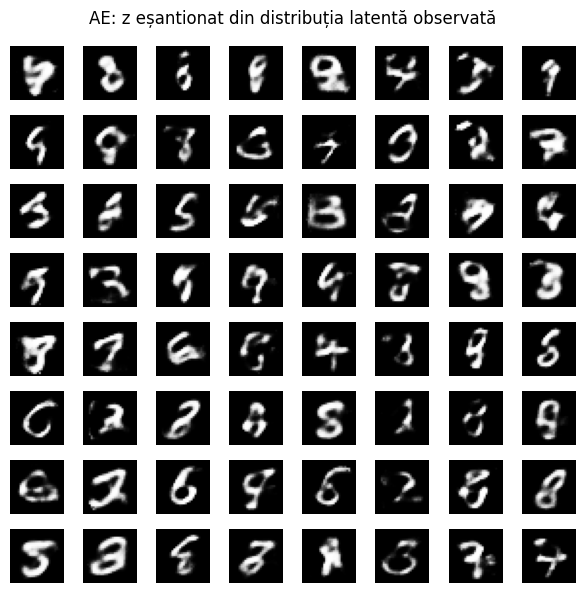

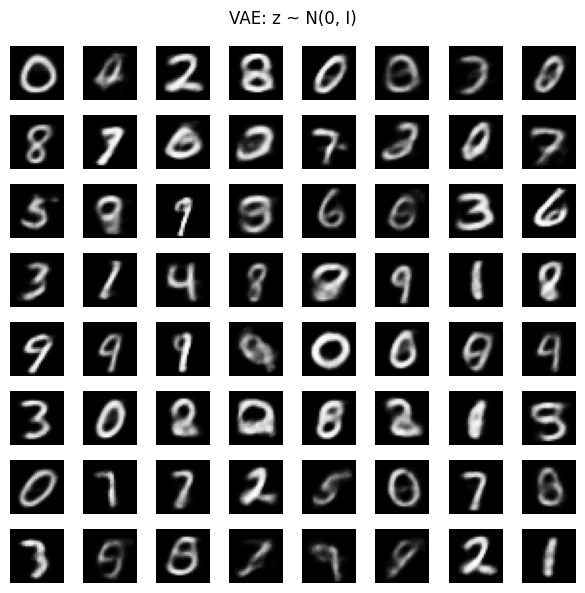

In [7]:
# Pentru VAE, N(0, I) este distribuția latentă impusă de termenul KL.
# Pentru AE, o generare corectă pornește din distribuția latentă observată pe datele de antrenare.
ae.eval()
vae_m.eval()
with torch.no_grad():
    latent_samples = []
    for x_batch, _ in train_dl:
        latent_samples.append(ae.encode(x_batch.to(device)).cpu())
        if sum(batch.size(0) for batch in latent_samples) >= 10000:
            break
    ae_latents = torch.cat(latent_samples)[:10000]
    ae_mean = ae_latents.mean(dim=0).to(device)
    ae_std = ae_latents.std(dim=0).clamp_min(1e-3).to(device)
    z_ae = ae_mean + torch.randn(64, LATENT, device=device) * ae_std
    z_vae = torch.randn(64, LATENT, device=device)
    gen_ae = ae.decode(z_ae).cpu()
    gen_vae = vae_m.decode(z_vae).cpu()


def show_grid(images, title, path):
    fig, axes = plt.subplots(8, 8, figsize=(6, 6))
    for axis, image in zip(axes.ravel(), images):
        axis.imshow(image[0], cmap='gray', vmin=0, vmax=1)
        axis.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.savefig(path, dpi=140)
    plt.show()

show_grid(gen_ae, 'AE: z eșantionat din distribuția latentă observată', 'generated_ae.png')
show_grid(gen_vae, 'VAE: z ~ N(0, I)', 'generated_vae.png')

## 8. Vizualizarea spațiilor latente

Un vector latent are `LATENT = 16` coordonate, deci nu îl putem desena direct într-un grafic obișnuit. Folosim **PCA** pentru a-l proiecta în două dimensiuni.

PCA caută două direcții care păstrează cât mai multă variație din date. Proiecția nu este o imagine completă a spațiului latent, ci doar o vedere simplificată.

În grafice:

- fiecare punct reprezintă o imagine MNIST;
- culoarea punctului reprezintă cifra reală, de la `0` la `9`;
- punctele apropiate au reprezentări latente asemănătoare.

Pentru AE folosim vectorul `z`. Pentru VAE folosim `mu`, adică centrul distribuției asociate imaginii. Dacă anumite cifre formează regiuni separate, înseamnă că encoderul a învățat reprezentări utile pentru diferențierea lor, chiar dacă etichetele nu au fost folosite la antrenare.

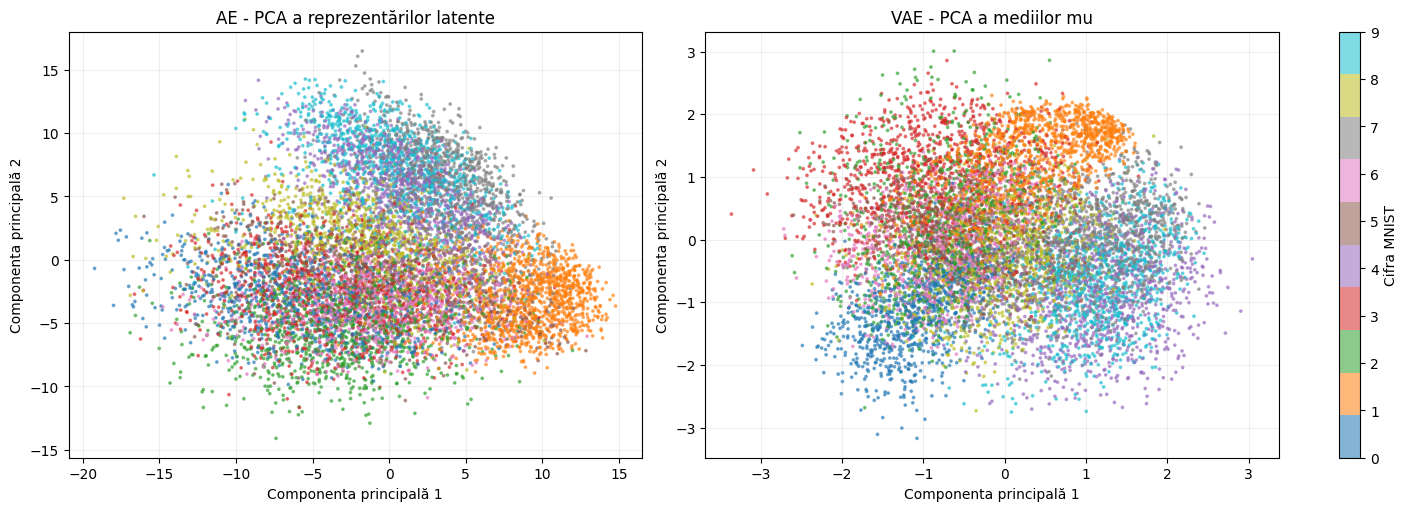

In [10]:
# Comparăm spațiile latente folosind aceeași proiecție PCA în 2D.
from sklearn.decomposition import PCA

zs_ae, zs_vae, labels = [], [], []
with torch.no_grad():
    for x_batch, y_batch in test_dl:
        x_batch = x_batch.to(device)
        zs_ae.append(ae.encode(x_batch).cpu())
        zs_vae.append(vae_m.encode(x_batch)[0].cpu())
        labels.append(y_batch)

z_ae_np = torch.cat(zs_ae).numpy()
z_vae_np = torch.cat(zs_vae).numpy()
y_np = torch.cat(labels).numpy()

pca_ae = PCA(n_components=2).fit_transform(z_ae_np)
pca_vae = PCA(n_components=2).fit_transform(z_vae_np)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for axis, coordinates, title in zip(
    axes,
    (pca_ae, pca_vae),
    ('AE - PCA a reprezentărilor latente', 'VAE - PCA a mediilor mu')
):
    scatter = axis.scatter(coordinates[:, 0], coordinates[:, 1], c=y_np, cmap='tab10', s=3, alpha=0.55)
    axis.set_title(title)
    axis.set_xlabel('Componenta principală 1')
    axis.set_ylabel('Componenta principală 2')
    axis.grid(alpha=0.2)
fig.colorbar(scatter, ax=axes, label='Cifra MNIST')
plt.savefig('latent_spaces.png', dpi=140)
plt.show()

## 9. Concluzii și interpretarea experimentului

### Ce am făcut?

Am antrenat două rețele care primesc imagini MNIST și încearcă să le reconstruiască:

- AE comprimă imaginea într-un vector `z` și optimizează reconstrucția;
- VAE comprimă imaginea într-o distribuție definită de `mu` și `logvar`, apoi regularizează această distribuție cu termenul KL.

### Ce rezultate ne așteptăm să vedem?

- **AE are de obicei MSE mai mic.** Nu trebuie să rezolve decât problema reconstrucției.
- **VAE poate reconstrui puțin mai neclar.** O parte din funcția lui de pierdere este folosită pentru a ordona spațiul latent.
- **VAE este mai potrivit pentru generare.** Putem alege `z ~ N(0, I)` și să îl trimitem în decoder.
- **AE este foarte bun pentru comprimare și reconstrucție.** Dar generarea din vectori aleatori este mai puțin sigură, deoarece distribuția latentă nu este controlată.

În rularea de referință, AE a avut aproximativ MSE `0.011`, iar VAE aproximativ MSE `0.022`. Valorile se pot schimba dacă modificăm numărul de epoci, dimensiunea latentă sau rata de învățare.

### Răspunsuri la întrebările importante

**1. Care model reconstruiește mai bine?**  
De regulă, AE, deoarece minimizează direct eroarea de reconstrucție. VAE acceptă un compromis pentru a obține un spațiu latent regulat.

**2. De ce VAE poate genera imagini noi?**  
Pentru că termenul KL apropie reprezentările de `N(0, I)`. Astfel, vectorii aleatori aleși din această distribuție au șanse mai mari să fie în zone utile ale spațiului latent.

**3. Ce se întâmplă dacă mărim `LATENT`?**  
Modelul primește mai mult spațiu pentru informație. Reconstrucția poate deveni mai bună, dar compresia este mai slabă și modelul poate învăța o reprezentare mai puțin simplă.

**4. Ce se întâmplă dacă termenul KL este prea puternic?**  
VAE este forțat prea tare spre `N(0, I)`, iar reconstrucțiile pot pierde detalii. Dacă este prea slab, generarea poate deveni mai puțin regulată.

### Experimente pe care le pot încerca

- schimb `LATENT` din `16` în `2`, apoi observ dacă reconstrucțiile se înrăutățesc;
- schimb `EPOCHS` și urmăresc dacă MSE-ul continuă să scadă;
- compar imaginile generate cu `z` apropiate, pentru a vedea interpolarea latentă;
- modific `beta` în funcția `vae_loss` pentru a controla cât de puternică este regularizarea KL.

### Concluzia mea

AE este alegerea potrivită când mă interesează în primul rând comprimarea și reconstrucția. VAE este mai potrivit când vreau și un model generativ, deoarece impune o structură continuă și controlabilă în spațiul latent. Diferența importantă nu este că unul este pur și simplu „mai bun”, ci că fiecare optimizează un obiectiv diferit.